In [13]:
import torch
import torch.nn as nn
import torchmetrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.manual_seed(42)

In [14]:
from pathlib import Path
import tarfile
import urllib.request

def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

In [15]:
path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [16]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


In [17]:
df.head(-1)

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-25,U,136680,103108
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065


<Axes: xlabel='date'>

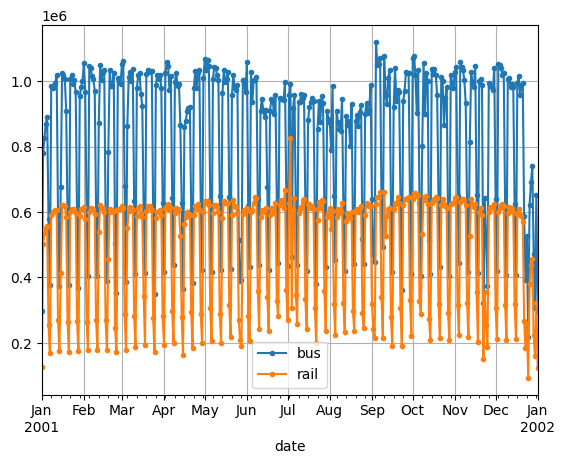

In [18]:
df["2001-01-01":"2002-01-01"].plot(grid=True, marker=".")

In [19]:
from torch.utils.data import DataLoader, Dataset


class period_14_days(Dataset):
    def __init__(self, series:torch.Tensor, window_length:int = 14):
        self.series = series
        self.window_length = window_length
    
    def __len__(self):
        return len(self.series) - self.window_length
    
    def __getitem__(self, idx) -> tuple[torch.Tensor, torch.Tensor]:
        end = idx + self.window_length
        window = self.series[idx:end]
        target = self.series[end]
        return window, target


rail_train = torch.FloatTensor(df[["rail", "bus"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail", "bus"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail", "bus"]]["2019-06":].values / 1e6)


torch.manual_seed(42)
window_length = 14
train_set = period_14_days(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = period_14_days(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32, shuffle=False)
test_set = period_14_days(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [20]:
class Seq2Seq(nn.Module):
    def __init__(self, input_size:int,hidden_size:int, output_size:int):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.encoder_cell = nn.Linear(input_size + hidden_size, hidden_size)
        self.decoder_cell = nn.Linear(output_size + hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
    
    def forward(self, X:torch.Tensor, target_len:int) -> torch.Tensor:
        batch_size, time_size, dimensionality = X.shape
        X_time_first = X.transpose(0,1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.encoder_cell(XH)
        
        outputs = []
        decoder_input = torch.zeros(batch_size, self.output_size, device=X.device)
        for _ in range(target_len):
            DH = torch.cat((decoder_input, H), dim=1)
            H = torch.tanh(self.decoder_cell(DH))
            out = self.output(H)
            outputs.append(out)
            decoder_input = out
            
        return torch.stack(outputs, dim=1)

In [21]:
X,y = next(iter(train_loader))
input_size, output_size = X.shape[-1], y.shape[-1]
hidden_size = 32
loss_fn = nn.HuberLoss()
model = Seq2Seq(input_size, hidden_size, output_size).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001,momentum=0.9)

def train(model:nn.Module, loss_fn:nn.Module, optimizer:torch.optim.Optimizer, dataloader:DataLoader, target_length:int=1, epoch:int = 1):
    model.train()
    optimizer.zero_grad()

    for i in range(epoch):
        total_loss:float = 0
        for idx, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)
            y_pred = model(X, target_length)
            y_pred.squeeze(1)
            loss = loss_fn(y_pred,y)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            print(f"epoch:{i}, batch:{idx}, loss:{loss}")

def test(model:nn.Module, loss_fn:nn.Module, dataloader:DataLoader, target_length:int = 1):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for idx, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)
            y_pred = model(X, target_length)
            loss = loss_fn(y_pred,y)
            total_loss += loss.item()
    
    print(f"avg loss: {total_loss/len(dataloader)}")

In [22]:
optimizer.zero_grad()
train(model, loss_fn, optimizer, train_loader)

epoch:0, batch:0, loss:0.20691001415252686
epoch:0, batch:1, loss:0.1679450124502182
epoch:0, batch:2, loss:0.18230223655700684
epoch:0, batch:3, loss:0.16281653940677643
epoch:0, batch:4, loss:0.1914224624633789
epoch:0, batch:5, loss:0.17120811343193054
epoch:0, batch:6, loss:0.15318411588668823
epoch:0, batch:7, loss:0.1596539169549942
epoch:0, batch:8, loss:0.16942083835601807
epoch:0, batch:9, loss:0.15638330578804016
epoch:0, batch:10, loss:0.16924504935741425
epoch:0, batch:11, loss:0.16284333169460297
epoch:0, batch:12, loss:0.1845165342092514
epoch:0, batch:13, loss:0.17100703716278076
epoch:0, batch:14, loss:0.1397039145231247
epoch:0, batch:15, loss:0.11786428838968277
epoch:0, batch:16, loss:0.14798499643802643
epoch:0, batch:17, loss:0.14203672111034393
epoch:0, batch:18, loss:0.11399365961551666
epoch:0, batch:19, loss:0.1276887059211731
epoch:0, batch:20, loss:0.15124580264091492
epoch:0, batch:21, loss:0.1375095546245575
epoch:0, batch:22, loss:0.11566606163978577
epoch

e:\Program\handson-mlp\.venv\Lib\site-packages\torch\nn\modules\loss.py:1144: UserWarning: Using a target size (torch.Size([32, 2])) that is different to the input size (torch.Size([32, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
e:\Program\handson-mlp\.venv\Lib\site-packages\torch\nn\modules\loss.py:1144: UserWarning: Using a target size (torch.Size([26, 2])) that is different to the input size (torch.Size([26, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


In [23]:
test(model, loss_fn, valid_loader)

avg loss: 0.08399684131145477


e:\Program\handson-mlp\.venv\Lib\site-packages\torch\nn\modules\loss.py:1144: UserWarning: Using a target size (torch.Size([9, 2])) that is different to the input size (torch.Size([9, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


In [24]:
test(model, loss_fn, test_loader)

avg loss: 0.02742120424076786


e:\Program\handson-mlp\.venv\Lib\site-packages\torch\nn\modules\loss.py:1144: UserWarning: Using a target size (torch.Size([4, 2])) that is different to the input size (torch.Size([4, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
